# EOM (Electro-Optic Modulator) Spectrum Analyzer

This notebook simulates the optical spectrum when multiple RF tones are applied to an EOM.

**Key Concepts:**
- Phase modulation creates sidebands at ω₀ ± nΩ
- Sideband amplitudes given by Bessel functions J_n(β)
- β = π·V_rf/V_π is the modulation depth
- Multiple tones create intermodulation products

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv  # Bessel function
from scipy.fft import fft, fftfreq

# For better plots
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11

## EOM Simulator Class

In [2]:
class EOMSimulator:
    """
    Simulates an Electro-Optic Modulator with multiple RF driving signals.
    """
    
    def __init__(self, carrier_wavelength=780e-9, sampling_rate=100e9, 
                 duration=10e-6, num_points=100000):
        self.carrier_wavelength = carrier_wavelength
        self.carrier_frequency = 3e8 / carrier_wavelength
        self.sampling_rate = sampling_rate
        self.duration = duration
        self.num_points = num_points
        self.time = np.linspace(0, duration, num_points)
        self.rf_signals = []
        
    def add_rf_tone(self, frequency, modulation_depth, phase=0, name=None):
        """Add an RF tone to modulate the EOM."""
        rf_dict = {
            'frequency': frequency,
            'modulation_depth': modulation_depth,
            'phase': phase,
            'name': name or f'RF Tone {len(self.rf_signals) + 1}'
        }
        self.rf_signals.append(rf_dict)
        
    def clear_rf_tones(self):
        """Clear all RF tones."""
        self.rf_signals = []
        
    def generate_modulation_signal(self):
        """Generate the total modulation signal from all RF tones."""
        modulation = np.zeros_like(self.time)
        
        for rf in self.rf_signals:
            freq = rf['frequency']
            beta = rf['modulation_depth']
            phase_rad = np.deg2rad(rf['phase'])
            modulation += beta * np.cos(2 * np.pi * freq * self.time + phase_rad)
        
        return modulation
    
    def generate_optical_field(self, modulation_type='phase'):
        """Generate the modulated optical field."""
        modulation = self.generate_modulation_signal()
        carrier_phase = 2 * np.pi * self.carrier_frequency * self.time
        
        if modulation_type == 'phase':
            field = np.exp(1j * (carrier_phase + modulation))
        else:
            field = (1 + modulation) * np.exp(1j * carrier_phase)
        
        return field
    
    def compute_optical_spectrum(self, modulation_type='phase', max_sidebands=10):
        """Compute optical spectrum using Bessel expansion (single tone) or FFT."""
        if len(self.rf_signals) == 1:
            rf = self.rf_signals[0]
            freq_rf = rf['frequency']
            beta = rf['modulation_depth']
            
            orders = np.arange(-max_sidebands, max_sidebands + 1)
            frequencies = orders * freq_rf
            
            if modulation_type == 'phase':
                spectrum = np.abs(jv(orders, beta))
            else:
                spectrum = np.zeros_like(frequencies, dtype=float)
                spectrum[orders == 0] = 1.0
                spectrum[orders == 1] = beta / 2
                spectrum[orders == -1] = beta / 2
        else:
            field = self.generate_optical_field(modulation_type)
            intensity = np.abs(field)**2
            
            spectrum_fft = fft(intensity - np.mean(intensity))
            freqs_fft = fftfreq(len(intensity), 1/self.sampling_rate)
            
            positive_idx = freqs_fft >= 0
            frequencies = freqs_fft[positive_idx]
            spectrum = np.abs(spectrum_fft[positive_idx])
            spectrum = spectrum / np.max(spectrum) if np.max(spectrum) > 0 else spectrum
            
        return frequencies, spectrum
    
    def plot_spectrum(self, modulation_type='phase', method='analytical', max_sidebands=10):
        """Plot the optical spectrum and modulation signals."""
        fig = plt.figure(figsize=(14, 10))
        gs = fig.add_gridspec(3, 1, hspace=0.3)
        
        # Plot 1: RF modulation
        ax1 = fig.add_subplot(gs[0])
        modulation = self.generate_modulation_signal()
        ax1.plot(self.time * 1e9, modulation, color='blue', linewidth=1.5)
        ax1.set_xlabel('Time (ns)')
        ax1.set_ylabel('Modulation β(t)')
        ax1.set_title('RF Modulation Signal (Combined)')
        ax1.grid(True, alpha=0.3)
        
        info_text = f"RF Tones: {len(self.rf_signals)}\n"
        for rf in self.rf_signals:
            info_text += f"{rf['name']}: {rf['frequency']/1e6:.1f} MHz, β={rf['modulation_depth']:.2f}\n"
        ax1.text(0.02, 0.98, info_text, transform=ax1.transAxes, 
                verticalalignment='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot 2: Optical field
        ax2 = fig.add_subplot(gs[1])
        field = self.generate_optical_field(modulation_type)
        plot_duration = min(100e-9, self.duration)
        plot_points = int(plot_duration * self.sampling_rate)
        ax2.plot(self.time[:plot_points] * 1e9, np.real(field[:plot_points]), 
                color='red', linewidth=0.5)
        ax2.set_xlabel('Time (ns)')
        ax2.set_ylabel('E(t) [Re]')
        ax2.set_title(f'Modulated Optical Field ({modulation_type.capitalize()} Modulation)')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Spectrum
        ax3 = fig.add_subplot(gs[2])
        frequencies, spectrum = self.compute_optical_spectrum(modulation_type, max_sidebands)
        
        markerline, stemlines, baseline = ax3.stem(frequencies/1e6, spectrum, 
                                                    linefmt='red', markerfmt='ro', basefmt='k-')
        markerline.set_markersize(6)
        stemlines.set_linewidth(1.5)
        
        ax3.set_xlabel('Frequency Relative to Carrier (MHz)')
        ax3.set_ylabel('Amplitude (normalized)')
        ax3.set_title(f'Optical Spectrum')
        ax3.grid(True, alpha=0.3)
        ax3.axvline(0, color='blue', linestyle='--', alpha=0.5, linewidth=2, label='Carrier')
        
        for rf in self.rf_signals:
            freq_mhz = rf['frequency'] / 1e6
            ax3.axvline(freq_mhz, color='green', linestyle=':', alpha=0.5)
            ax3.axvline(-freq_mhz, color='green', linestyle=':', alpha=0.5)
        
        ax3.legend()
        ax3.set_ylim([0, max(1.1, np.max(spectrum) * 1.1)])
        
        plt.tight_layout()
        return fig

## Configuration - Edit These Parameters!

In [3]:
# ============================================================================
# CONFIGURATION: Edit these parameters for your EOM
# ============================================================================

# Optical carrier
carrier_wavelength = 780e-9  # 780 nm (Rubidium D2 line)
modulation_type = 'phase'     # 'phase' or 'amplitude'

# RF tones applied to EOM
rf_frequencies = [10e6, 20e6]        # RF frequencies in Hz
modulation_depths = [1.5, 0.8]       # Modulation depths β
rf_phases = [0, 0]                   # Phases in degrees
rf_names = ['Tone 1', 'Tone 2']      # Optional names

# Simulation parameters
sampling_rate = 100e9    # 100 GHz
duration = 10e-6         # 10 microseconds
num_points = 100000      # Time points

# Plotting
max_sidebands = 10       # Max sidebands to show

## Run Simulation

In [4]:
# Create EOM simulator
eom = EOMSimulator(
    carrier_wavelength=carrier_wavelength,
    sampling_rate=sampling_rate,
    duration=duration,
    num_points=num_points
)

# Add RF tones
for i, (freq, beta, phase) in enumerate(zip(rf_frequencies, modulation_depths, rf_phases)):
    name = rf_names[i] if i < len(rf_names) else f"RF{i+1}"
    eom.add_rf_tone(frequency=freq, modulation_depth=beta, phase=phase, name=name)

# Print configuration
print(f"EOM Configuration:")
print(f"Carrier wavelength: {carrier_wavelength*1e9:.1f} nm")
print(f"Carrier frequency: {eom.carrier_frequency/1e12:.3f} THz")
print(f"Modulation type: {modulation_type}")
print(f"\nRF Tones ({len(rf_frequencies)}):")
for i, (freq, beta) in enumerate(zip(rf_frequencies, modulation_depths)):
    print(f"  {i+1}. Frequency: {freq/1e6:.3f} MHz, β: {beta:.3f}")

EOM Configuration:
Carrier wavelength: 780.0 nm
Carrier frequency: 384.615 THz
Modulation type: phase

RF Tones (2):
  1. Frequency: 10.000 MHz, β: 1.500
  2. Frequency: 20.000 MHz, β: 0.800


## Plot Results

C:\Users\iamga\AppData\Local\Temp\ipykernel_41268\658801704.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


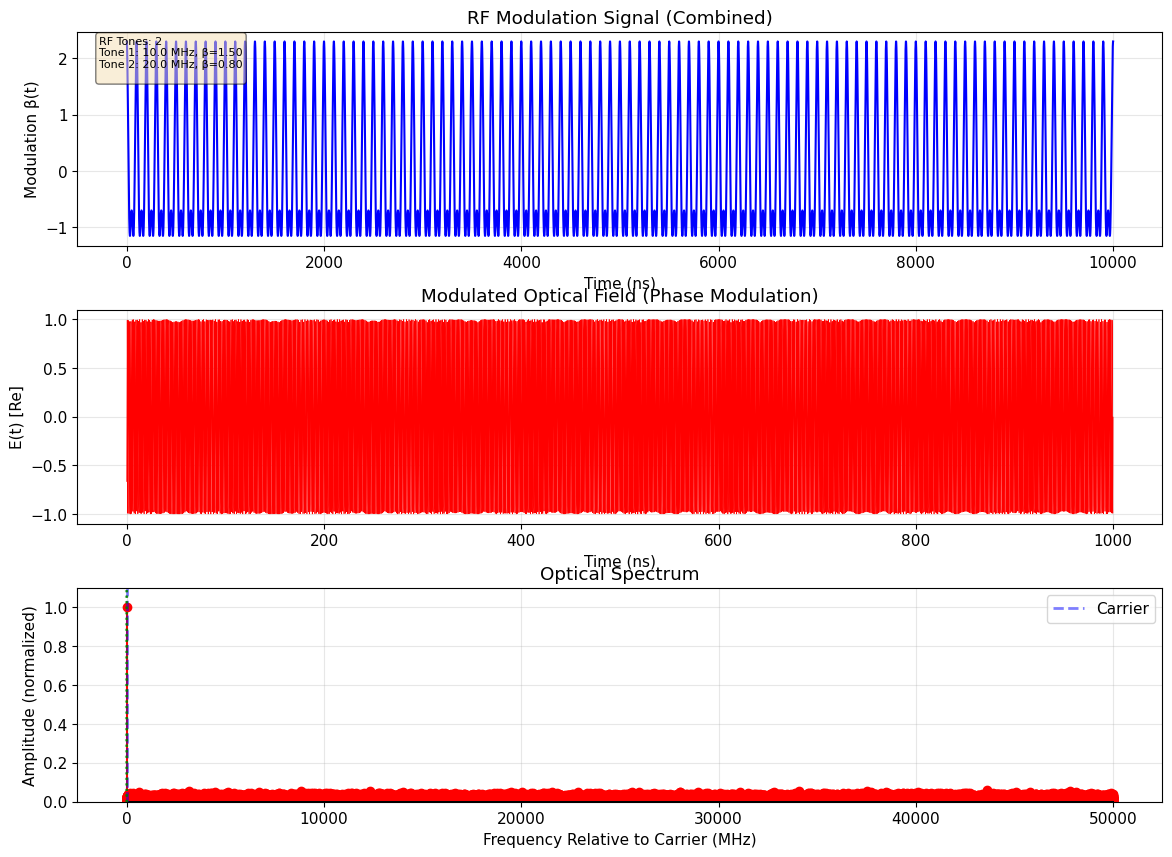

In [5]:
fig = eom.plot_spectrum(modulation_type=modulation_type, max_sidebands=max_sidebands)
plt.show()

## Analysis: Bessel Function Sidebands

For a single tone with modulation depth β, the sideband amplitudes are:
$$E_n = J_n(\beta) e^{i(\omega_c + n\Omega)t}$$

Let's visualize how β affects the sidebands:

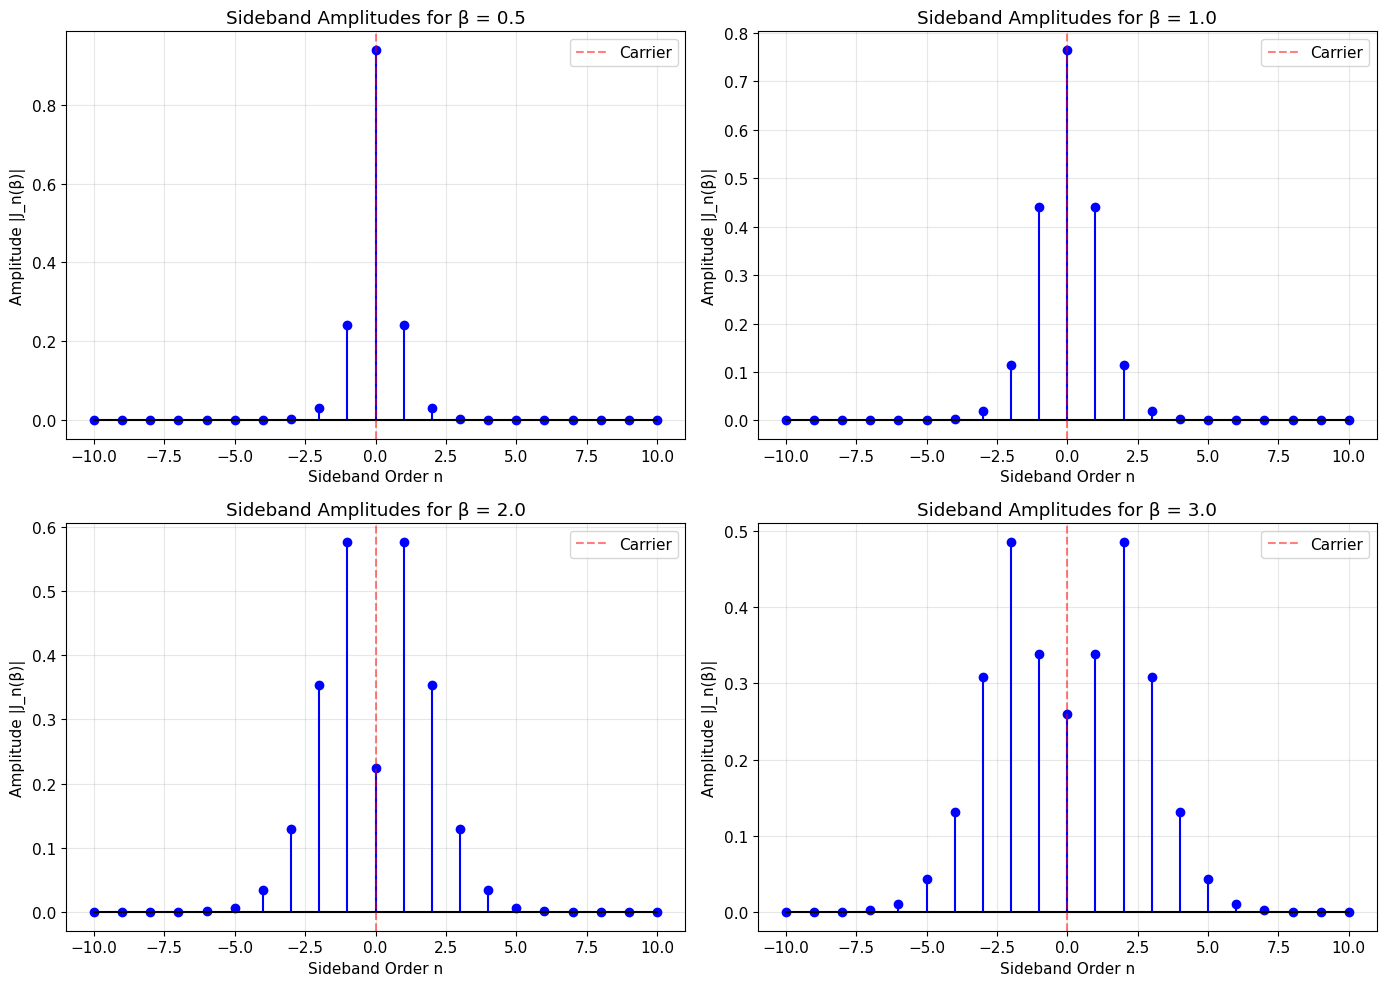

In [6]:
# Plot Bessel function amplitudes for different β
beta_values = [0.5, 1.0, 2.0, 3.0]
orders = np.arange(-10, 11)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, beta in enumerate(beta_values):
    amplitudes = np.abs(jv(orders, beta))
    axes[i].stem(orders, amplitudes, linefmt='blue', markerfmt='bo', basefmt='k-')
    axes[i].set_xlabel('Sideband Order n')
    axes[i].set_ylabel('Amplitude |J_n(β)|')
    axes[i].set_title(f'Sideband Amplitudes for β = {beta}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5, label='Carrier')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Quick Examples

### Example 1: Single Tone

C:\Users\iamga\AppData\Local\Temp\ipykernel_41268\658801704.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


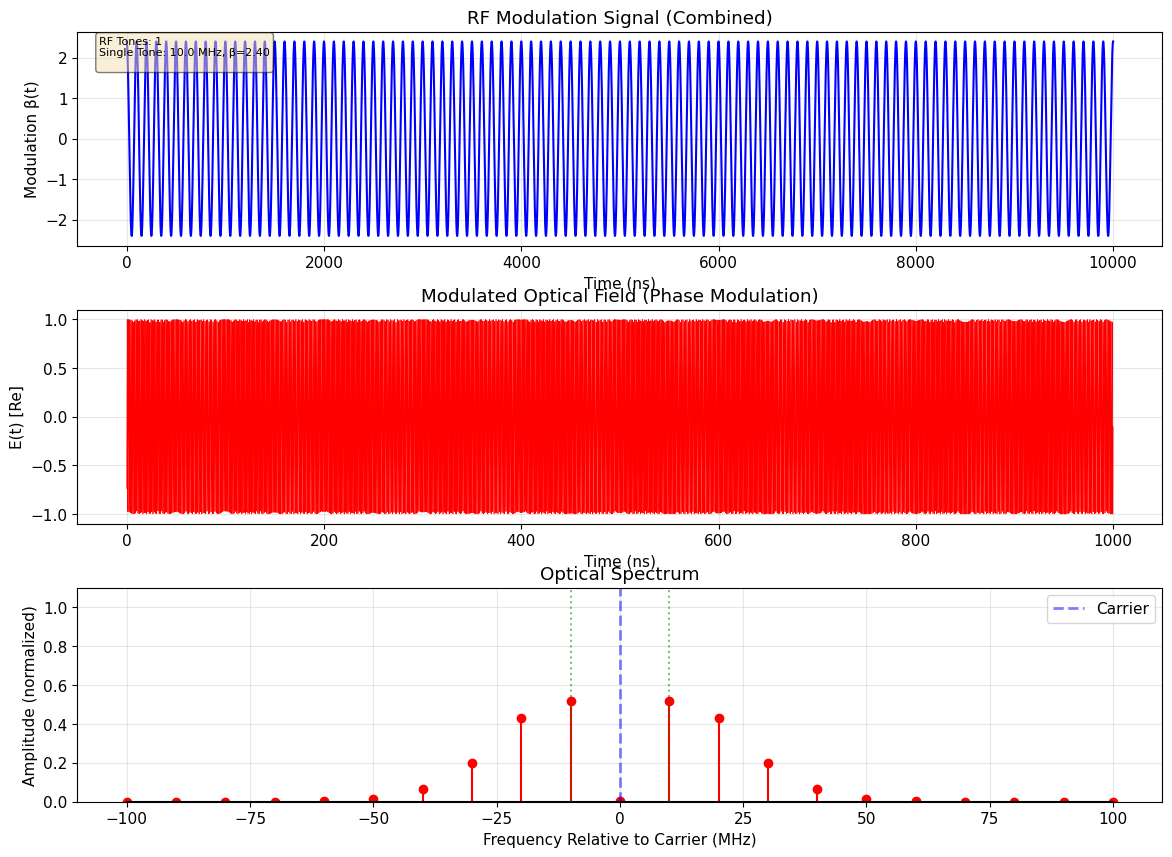


Note: β=2.4 corresponds to carrier suppression (J₀(2.4) ≈ 0)


In [7]:
eom1 = EOMSimulator(carrier_wavelength=780e-9)
eom1.add_rf_tone(frequency=10e6, modulation_depth=2.4, name='Single Tone')
fig1 = eom1.plot_spectrum(modulation_type='phase', max_sidebands=10)
plt.show()

print("\nNote: β=2.4 corresponds to carrier suppression (J₀(2.4) ≈ 0)")

### Example 2: Two Tones (Frequency Comb)

C:\Users\iamga\AppData\Local\Temp\ipykernel_41268\658801704.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


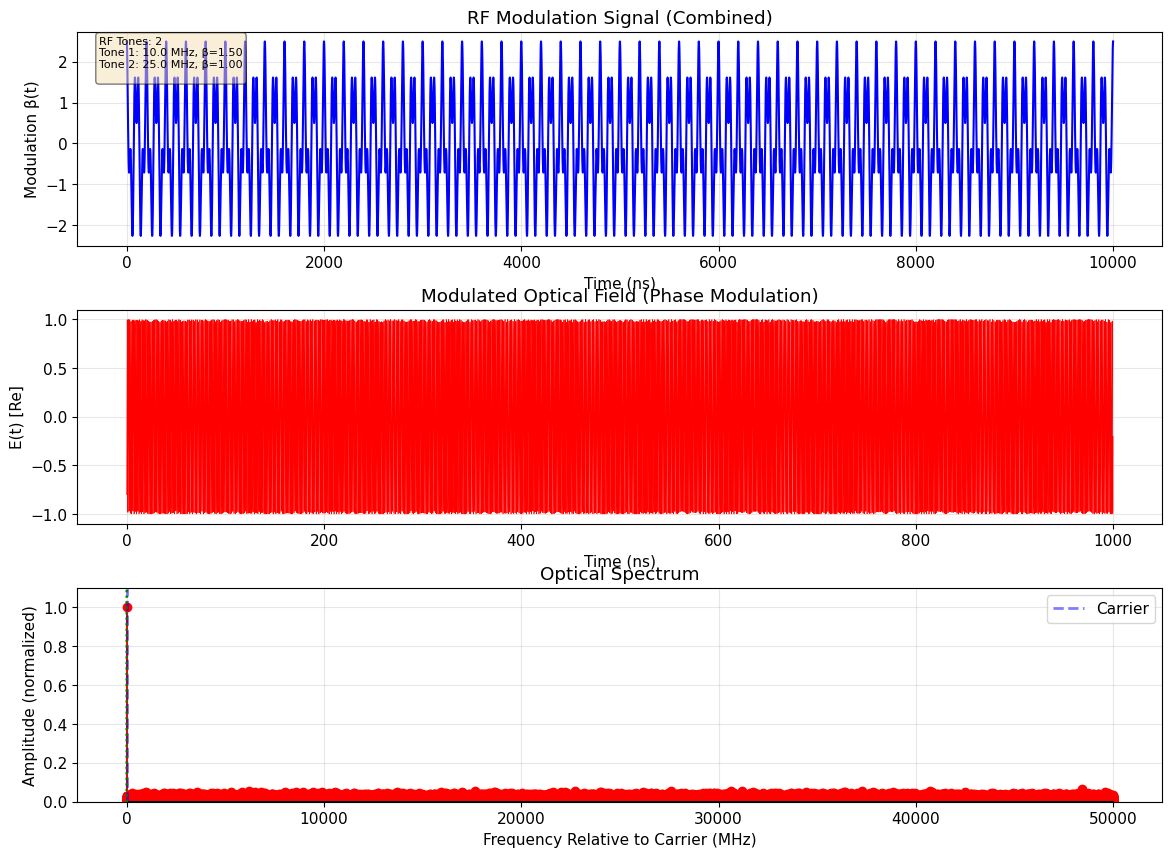

In [8]:
eom2 = EOMSimulator(carrier_wavelength=780e-9)
eom2.add_rf_tone(frequency=10e6, modulation_depth=1.5, name='Tone 1')
eom2.add_rf_tone(frequency=25e6, modulation_depth=1.0, name='Tone 2')
fig2 = eom2.plot_spectrum(modulation_type='phase', max_sidebands=8)
plt.show()

### Example 3: Three Tones

C:\Users\iamga\AppData\Local\Temp\ipykernel_41268\658801704.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


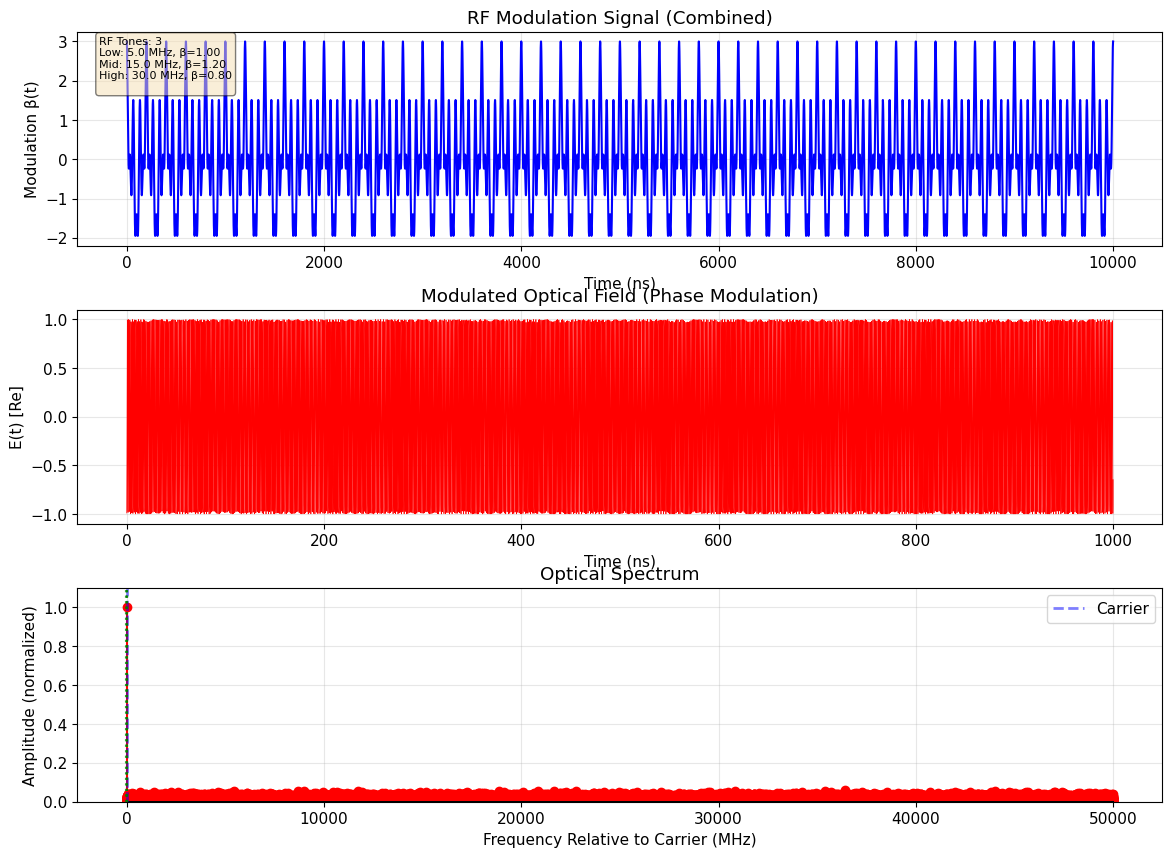

In [9]:
eom3 = EOMSimulator(carrier_wavelength=780e-9)
eom3.add_rf_tone(frequency=5e6, modulation_depth=1.0, name='Low')
eom3.add_rf_tone(frequency=15e6, modulation_depth=1.2, name='Mid')
eom3.add_rf_tone(frequency=30e6, modulation_depth=0.8, name='High')
fig3 = eom3.plot_spectrum(modulation_type='phase', max_sidebands=8)
plt.show()